# HR ANALYTICS
# Recruitment, Performance & Attrition


## 1. IMPORT LIBRARIES


In [94]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Optional: display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.2f}')

## 2. LOAD DATA

In [95]:
file_path = r"C:\Users\Suraj\Desktop\projects\HR_Analytics\data\Recruitment_Data_updated.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Dataset loaded successfully.
Rows: 107,354
Columns: 4


## 3. INITIAL DATA INSPECTION

In [96]:
print("\n--- First 5 Rows ---")
display(df.head())

print("\n--- Dataset Information ---")
df.info()

print("\n--- Statistical Summary ---")
display(df.describe())

print("\n--- Missing Values ---")
missing_values = df.isnull().sum()

missing_summary = pd.DataFrame({
    'Missing Values': missing_values,
    'Missing %': (missing_values / len(df) * 100).round(2)
})

display(missing_summary)

print("\n--- Duplicate Rows ---")
print(df.duplicated().sum())


--- First 5 Rows ---


,attrition,performance_rating,sales_quota_pct,recruiting_source
0,0.00,2.98,0.60,Applied Online
1,-0.02,2.99,0.40,NaN
2,-0.01,2.99,0.21,Applied Online
3,-0.00,1.99,-0.48,NaN
4,-0.03,3.02,0.35,Campus



--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107354 entries, 0 to 107353
Data columns (total 4 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   attrition           107354 non-null  float64
 1   performance_rating  107354 non-null  float64
 2   sales_quota_pct     107354 non-null  float64
 3   recruiting_source   57753 non-null   object 
dtypes: float64(3), object(1)
memory usage: 3.3+ MB

--- Statistical Summary ---


,attrition,performance_rating,sales_quota_pct
count,107354.00,107354.00,107354.00
mean,0.21,2.90,1.08
std,0.41,0.68,0.71
min,-0.04,0.96,-0.74
25%,-0.00,2.02,0.59
50%,0.00,3.00,1.07
75%,0.02,3.01,1.53
max,1.04,5.03,3.70



--- Missing Values ---


,Missing Values,Missing %
attrition,0,0.00
performance_rating,0,0.00
sales_quota_pct,0,0.00
recruiting_source,49601,46.20



--- Duplicate Rows ---
0


## 4. CHECK UNIQUE VALUES IN CATEGORICAL FIELD

In [97]:

print("\n--- Recruiting Sources ---")

print(df['recruiting_source'].value_counts(dropna=False))


--- Recruiting Sources ---
recruiting_source
NaN               49601
Applied Online    30966
Campus            13453
Referral          10926
Search Firm        2408
Name: count, dtype: int64


## 5. Create a Binary Attrition Flag

The `Attrition` column contains small numeric variations around `0` and `1` rather than strictly binary values.

To standardize the values, we create a binary `attrition_flag` using the following rule:

- **`>= 0.5` → Employee left**
- **`< 0.5` → Employee stayed**

The `attrition_flag` is used for all subsequent **attrition rate calculations and analysis**.

In [98]:

df['attrition_flag'] = (df['attrition'] >= 0.5).astype(int)

print("\n--- Attrition Flag Distribution ---")

attrition_count = df['attrition_flag'].value_counts().sort_index()
print(attrition_count)

attrition_summary = pd.DataFrame({
    'Employee Status': ['Stayed', 'Left'],
    'Employee Count': [
        attrition_count.get(0, 0),
        attrition_count.get(1, 0)
    ]
})

display(attrition_summary)


--- Attrition Flag Distribution ---
attrition_flag
0    84465
1    22889
Name: count, dtype: int64


,Employee Status,Employee Count
0,Stayed,84465
1,Left,22889


## 6. OVERALL ATTRITION ANALYSIS

In [99]:

total_employees = len(df)
employees_left = df['attrition_flag'].sum()
employees_stayed = total_employees - employees_left
overall_attrition_rate = (
    df['attrition_flag'].mean() * 100
)

print(f"Total Employees/Records : {total_employees:,}")
print(f"Employees Stayed        : {employees_stayed:,}")
print(f"Employees Left          : {employees_left:,}")
print(f"Overall Attrition Rate  : {overall_attrition_rate:.2f}%")

Total Employees/Records : 107,354
Employees Stayed        : 84,465
Employees Left          : 22,889
Overall Attrition Rate  : 21.32%


## 7. ATTRITION DISTRIBUTION VISUAL

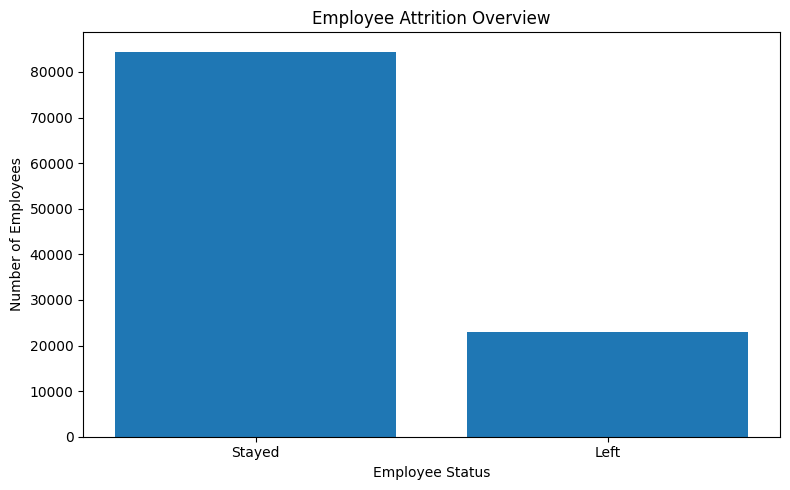

In [100]:

status_labels = ['Stayed', 'Left']
status_counts = [employees_stayed, employees_left]

plt.figure(figsize=(8, 5))

plt.bar(status_labels, status_counts)

plt.title('Employee Attrition Overview')
plt.xlabel('Employee Status')
plt.ylabel('Number of Employees')

plt.tight_layout()
plt.show()


## 8. ATTRITION RATE BY RECRUITING SOURCE
### Missing recruiting sources are retained as
### "Missing / Not Recorded".
### This is important because removing these records could
### distort the comparison.

In [101]:
df['recruiting_source_clean'] = (
    df['recruiting_source']
    .fillna('Missing / Not Recorded')
)

source_summary = (
    df.groupby('recruiting_source_clean')
      .agg(
          employees=('attrition_flag', 'size'),
          attrition_rate=('attrition_flag', 'mean'),
          avg_performance=('performance_rating', 'mean'),
          avg_quota=('sales_quota_pct', 'mean')
      )
      .reset_index()
)

source_summary['attrition_rate'] = (
    source_summary['attrition_rate'] * 100
)

source_summary = source_summary.sort_values(
    'attrition_rate',
    ascending=False
)

print("\n--- Recruiting Source Summary ---")

display(source_summary)


--- Recruiting Source Summary ---


,recruiting_source_clean,employees,attrition_rate,avg_performance,avg_quota
1,Campus,13453,21.52,2.89,1.08
3,Referral,10926,21.50,2.91,1.08
0,Applied Online,30966,21.34,2.89,1.08
2,Missing / Not Recorded,49601,21.24,2.90,1.09
4,Search Firm,2408,20.81,2.90,1.10


## 9. RECRUITING SOURCE — ATTRITION RATE

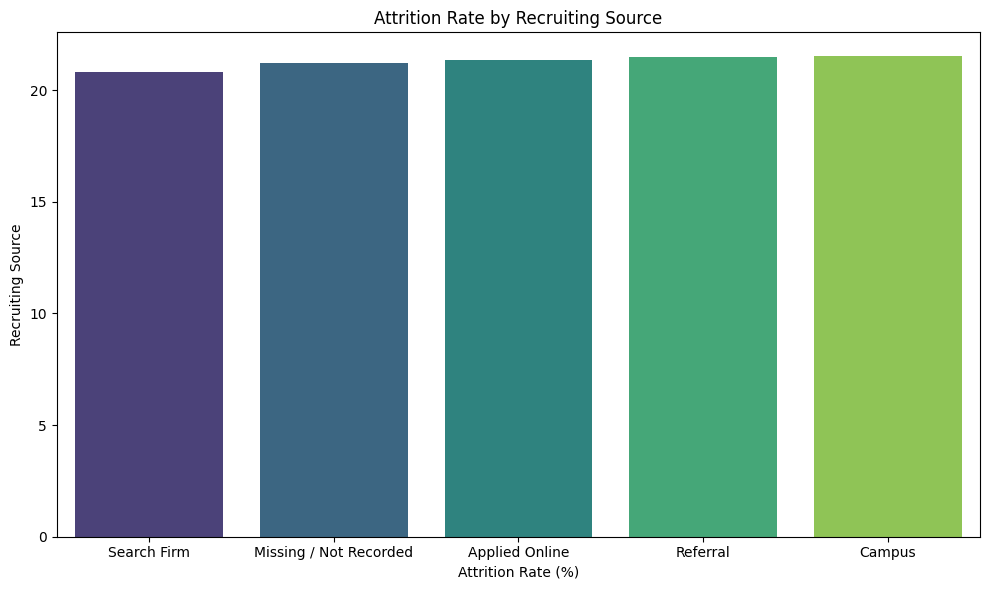

In [102]:

source_plot = source_summary.sort_values(
    'attrition_rate',
    ascending=True
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=source_plot,
    x='recruiting_source_clean',
    y='attrition_rate',
    hue='recruiting_source_clean',
    palette='viridis',
    legend=False
)

plt.xlabel('Attrition Rate (%)')
plt.ylabel('Recruiting Source')
plt.title('Attrition Rate by Recruiting Source')

plt.tight_layout()
plt.show()

## 10. RECRUITING SOURCE — EMPLOYEE COUNT

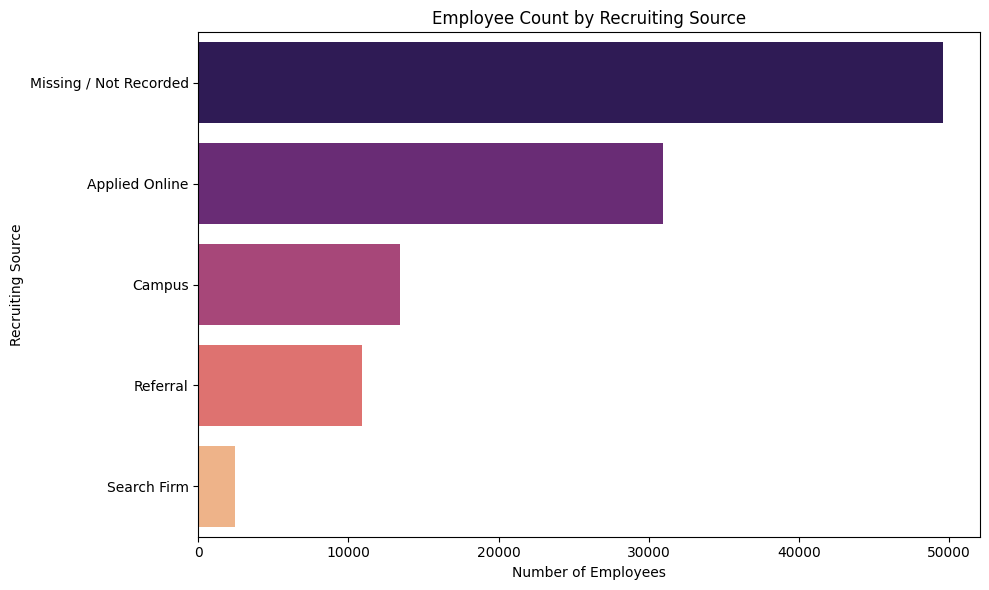

In [103]:

source_count_plot = source_summary.sort_values(
    'employees',
    ascending=False
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=source_count_plot,
    x='employees',
    y='recruiting_source_clean',
    hue='recruiting_source_clean',
    palette='magma',
    legend=False
)

plt.xlabel('Number of Employees')
plt.ylabel('Recruiting Source')
plt.title('Employee Count by Recruiting Source')

plt.tight_layout()
plt.show()

## 11. RECRUITING SOURCE — PERFORMANCE

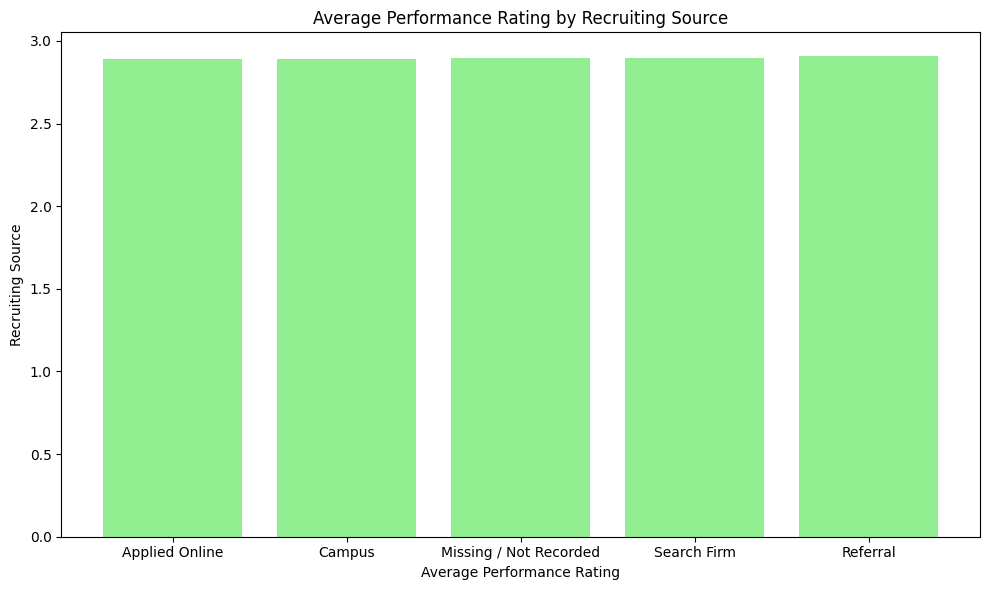

In [104]:

performance_source_plot = source_summary.sort_values(
    'avg_performance',
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.bar(
    performance_source_plot['recruiting_source_clean'],
    performance_source_plot['avg_performance'],
    color = '#90EE90'
)

plt.xlabel('Average Performance Rating')
plt.ylabel('Recruiting Source')
plt.title('Average Performance Rating by Recruiting Source')

plt.tight_layout()
plt.show()

## 12. RECRUITING SOURCE — SALES QUOTA

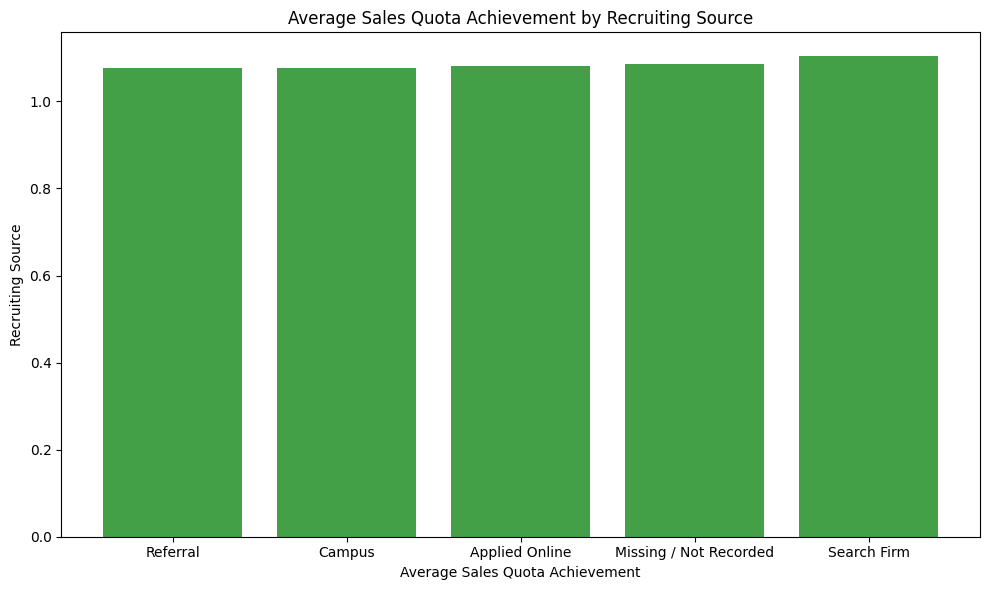

In [105]:

quota_source_plot = source_summary.sort_values(
    'avg_quota',
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.bar(
    quota_source_plot['recruiting_source_clean'],
    quota_source_plot['avg_quota'],
    color = '#43A047'
)

plt.xlabel('Average Sales Quota Achievement')
plt.ylabel('Recruiting Source')
plt.title('Average Sales Quota Achievement by Recruiting Source')

plt.tight_layout()
plt.show()

## 13. PERFORMANCE ANALYSIS

In [106]:

print("\n--- Performance Rating Summary ---")

performance_summary = (
    df.groupby('attrition_flag')['performance_rating']
      .agg(['count', 'mean', 'median', 'min', 'max'])
      .reset_index()
)

performance_summary['Employee Status'] = (
    performance_summary['attrition_flag']
    .map({
        0: 'Stayed',
        1: 'Left'
    })
)

performance_summary = performance_summary[
    [
        'Employee Status',
        'count',
        'mean',
        'median',
        'min',
        'max'
    ]
]

display(performance_summary)



--- Performance Rating Summary ---


,Employee Status,count,mean,median,min,max
0,Stayed,84465,2.90,3.00,0.96,5.03
1,Left,22889,2.87,3.00,0.97,4.03


In [107]:
## 14. PERFORMANCE BY ATTRITION STATUS

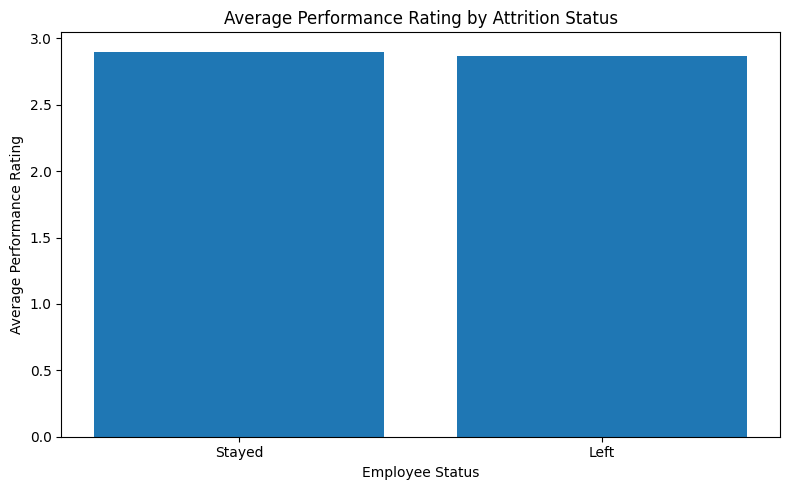

In [108]:

performance_by_status = (
    df.groupby('attrition_flag')['performance_rating']
      .mean()
      .reset_index()
)

performance_by_status['Employee Status'] = (
    performance_by_status['attrition_flag']
    .map({
        0: 'Stayed',
        1: 'Left'
    })
)

plt.figure(figsize=(8, 5))

plt.bar(
    performance_by_status['Employee Status'],
    performance_by_status['performance_rating']
)

plt.xlabel('Employee Status')
plt.ylabel('Average Performance Rating')
plt.title('Average Performance Rating by Attrition Status')

plt.tight_layout()
plt.show()

## 15. SALES QUOTA ANALYSIS

In [109]:

print("\n--- Sales Quota Summary ---")

quota_summary = (
    df.groupby('attrition_flag')['sales_quota_pct']
      .agg(['count', 'mean', 'median', 'min', 'max'])
      .reset_index()
)

quota_summary['Employee Status'] = (
    quota_summary['attrition_flag']
    .map({
        0: 'Stayed',
        1: 'Left'
    })
)

quota_summary = quota_summary[
    [
        'Employee Status',
        'count',
        'mean',
        'median',
        'min',
        'max'
    ]
]

display(quota_summary)


--- Sales Quota Summary ---


,Employee Status,count,mean,median,min,max
0,Stayed,84465,1.10,1.06,-0.74,3.70
1,Left,22889,1.03,1.08,-0.66,3.26


## 16. SALES QUOTA BY ATTRITION STATUS

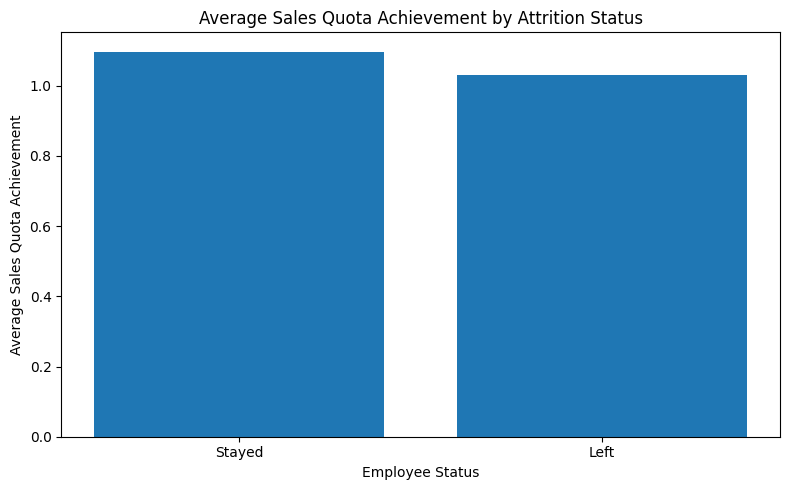

In [110]:

quota_by_status = (
    df.groupby('attrition_flag')['sales_quota_pct']
      .mean()
      .reset_index()
)

quota_by_status['Employee Status'] = (
    quota_by_status['attrition_flag']
    .map({
        0: 'Stayed',
        1: 'Left'
    })
)

plt.figure(figsize=(8, 5))

plt.bar(
    quota_by_status['Employee Status'],
    quota_by_status['sales_quota_pct']
)

plt.xlabel('Employee Status')
plt.ylabel('Average Sales Quota Achievement')
plt.title('Average Sales Quota Achievement by Attrition Status')

plt.tight_layout()
plt.show()

## 17. PERFORMANCE VS SALES QUOTA
### This visual is used to understand the relationship between
### performance and quota achievement.
### We do NOT interpret this as proof of causation.

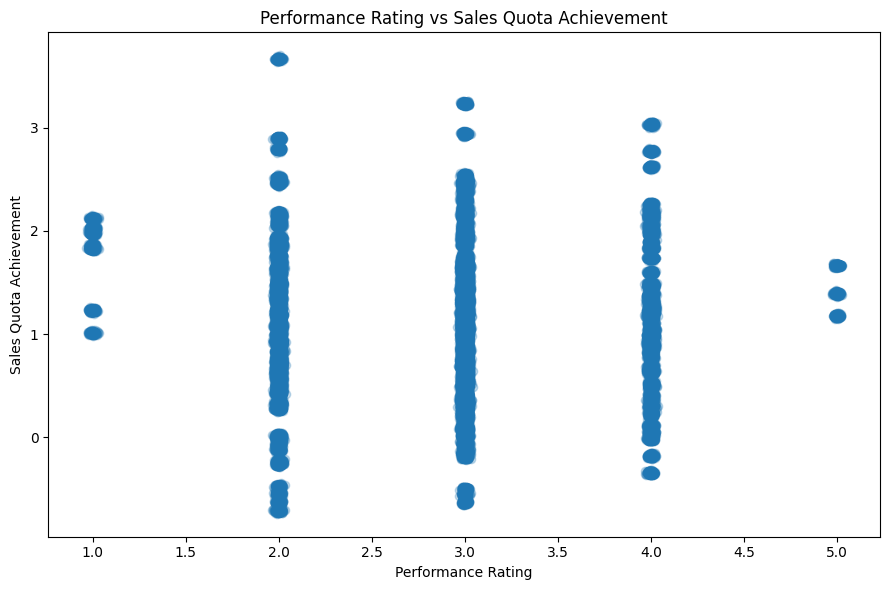

In [111]:

plt.figure(figsize=(9, 6))

plt.scatter(
    df['performance_rating'],
    df['sales_quota_pct'],
    alpha=0.25
)

plt.xlabel('Performance Rating')
plt.ylabel('Sales Quota Achievement')
plt.title('Performance Rating vs Sales Quota Achievement')

plt.tight_layout()
plt.show()

## 18. CORRELATION ANALYSIS
### Correlation is used only as a directional measure of
### association, not causation.

In [112]:

correlation_data = df[
    [
        'attrition_flag',
        'performance_rating',
        'sales_quota_pct'
    ]
]

correlation_matrix = correlation_data.corr()

print("\n--- Correlation Matrix ---")

display(correlation_matrix)



--- Correlation Matrix ---


,attrition_flag,performance_rating,sales_quota_pct
attrition_flag,1.00,-0.02,-0.04
performance_rating,-0.02,1.00,-0.01
sales_quota_pct,-0.04,-0.01,1.00


## 19. CORRELATION HEATMAP

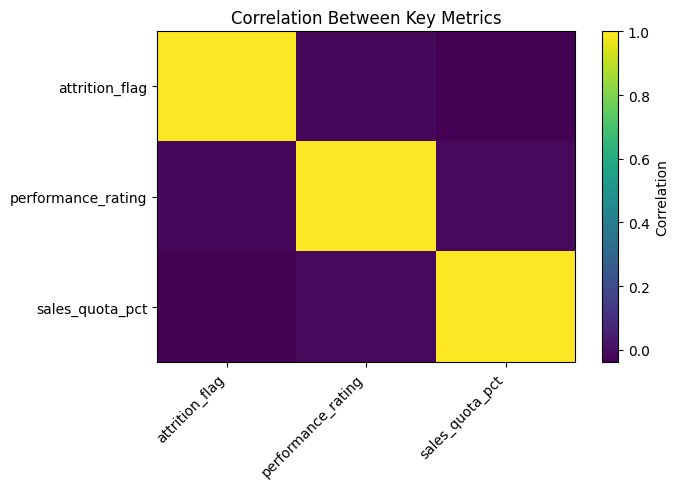

In [113]:

plt.figure(figsize=(7, 5))

plt.imshow(
    correlation_matrix,
    interpolation='nearest',
    aspect='auto'
)

plt.colorbar(label='Correlation')

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha='right'
)

plt.yticks(
    range(len(correlation_matrix.index)),
    correlation_matrix.index
)

plt.title('Correlation Between Key Metrics')

plt.tight_layout()
plt.show()


## 20. KPI SUMMARY

In [114]:

avg_performance = df['performance_rating'].mean()

avg_quota = df['sales_quota_pct'].mean()

recorded_source_pct = (
    df['recruiting_source'].notna().mean() * 100
)

missing_source_pct = (
    df['recruiting_source'].isna().mean() * 100
)

kpi_summary = pd.DataFrame({
    'Metric': [
        'Total Employees/Records',
        'Employees Left',
        'Overall Attrition Rate',
        'Average Performance Rating',
        'Average Sales Quota Achievement',
        'Recruiting Source Recorded',
        'Recruiting Source Missing'
    ],
    'Value': [
        f'{total_employees:,}',
        f'{employees_left:,}',
        f'{overall_attrition_rate:.2f}%',
        f'{avg_performance:.2f}',
        f'{avg_quota:.2f}',
        f'{recorded_source_pct:.2f}%',
        f'{missing_source_pct:.2f}%'
    ]
})

print("\n--- KPI Summary ---")

display(kpi_summary)


--- KPI Summary ---


,Metric,Value
0,Total Employees/Records,"107,354"
1,Employees Left,"22,889"
2,Overall Attrition Rate,21.32%
3,Average Performance Rating,2.90
4,Average Sales Quota Achievement,1.08
5,Recruiting Source Recorded,53.80%
6,Recruiting Source Missing,46.20%


## 21. TOP / LOWEST ATTRITION SOURCE

### Exclude the missing category when identifying actual
### recruiting sources.

In [115]:

named_sources = source_summary[
    source_summary['recruiting_source_clean']
    != 'Missing / Not Recorded'
].copy()

highest_attrition_source = (
    named_sources
    .sort_values('attrition_rate', ascending=False)
    .iloc[0]
)

lowest_attrition_source = (
    named_sources
    .sort_values('attrition_rate', ascending=True)
    .iloc[0]
)

print("\n--- Recruiting Source Signals ---")

print(
    f"Highest observed attrition: "
    f"{highest_attrition_source['recruiting_source_clean']} "
    f"({highest_attrition_source['attrition_rate']:.2f}%)"
)

print(
    f"Lowest observed attrition: "
    f"{lowest_attrition_source['recruiting_source_clean']} "
    f"({lowest_attrition_source['attrition_rate']:.2f}%)"
)


--- Recruiting Source Signals ---
Highest observed attrition: Campus (21.52%)
Lowest observed attrition: Search Firm (20.81%)


## 22. SOURCE ATTRITION RANGE

In [116]:

source_attrition_range = (
    named_sources['attrition_rate'].max()
    - named_sources['attrition_rate'].min()
)

print(
    f"\nDifference between highest and lowest named "
    f"recruiting-source attrition: "
    f"{source_attrition_range:.2f} percentage points"
)


Difference between highest and lowest named recruiting-source attrition: 0.71 percentage points


## 23. BUSINESS INSIGHTS

In [117]:

print("\n" + "=" * 60)
print("BUSINESS INSIGHTS")
print("=" * 60)

print(f"""
1. Overall Attrition
   The overall observed attrition rate is {overall_attrition_rate:.2f}%.
   This provides the baseline against which recruiting sources
   can be compared.

2. Recruiting Source
   Attrition rates vary across recruiting sources, but the
   differences are relatively modest.
   This suggests that recruiting source alone is not enough
   to explain employee turnover.

3. Search Firm
   Search Firm has the lowest observed attrition among the
   named recruiting sources.
   This should be treated as a signal to monitor rather than
   proof that it is the best recruitment channel.

4. Missing Recruitment Data
   {missing_source_pct:.2f}% of records have no recorded
   recruiting source.
   This is an important data-quality limitation because
   incomplete source information reduces confidence in
   recruitment-channel comparisons.

5. Performance
   Employees who stayed have an average performance rating
   of {df.loc[df['attrition_flag'] == 0, 'performance_rating'].mean():.2f},
   compared with {df.loc[df['attrition_flag'] == 1, 'performance_rating'].mean():.2f}
   among employees who left.

6. Sales Quota
   Employees who stayed have an average sales quota achievement
   of {df.loc[df['attrition_flag'] == 0, 'sales_quota_pct'].mean():.2f},
   compared with {df.loc[df['attrition_flag'] == 1, 'sales_quota_pct'].mean():.2f}
   among employees who left.

7. Interpretation
   These differences describe patterns in the dataset.
   They should not be interpreted as proof that performance,
   quota achievement, or recruiting source causes attrition.
""")


BUSINESS INSIGHTS

1. Overall Attrition
   The overall observed attrition rate is 21.32%.
   This provides the baseline against which recruiting sources
   can be compared.

2. Recruiting Source
   Attrition rates vary across recruiting sources, but the
   differences are relatively modest.
   This suggests that recruiting source alone is not enough
   to explain employee turnover.

3. Search Firm
   Search Firm has the lowest observed attrition among the
   named recruiting sources.
   This should be treated as a signal to monitor rather than
   proof that it is the best recruitment channel.

4. Missing Recruitment Data
   46.20% of records have no recorded
   recruiting source.
   This is an important data-quality limitation because
   incomplete source information reduces confidence in
   recruitment-channel comparisons.

5. Performance
   Employees who stayed have an average performance rating
   of 2.90,
   compared with 2.87
   among employees who left.

6. Sales Quota
   Employ

## 24. RECOMMENDATIONS

In [118]:

print("\n" + "=" * 60)
print("HR RECOMMENDATIONS")
print("=" * 60)

print("""
1. Do not evaluate recruiting channels using attrition alone.
   Consider retention, performance, hiring volume, time-to-fill,
   and cost-per-hire together.

2. Improve recruiting-source data capture.
   A consistently recorded source for every hire would make
   future recruitment-channel analysis more reliable.

3. Monitor sources with lower observed attrition over time.
   A single-period comparison should be validated before making
   major recruitment-investment decisions.

4. Combine recruitment data with employee-level information.
   Variables such as tenure, compensation, role, department,
   manager, promotion history, workload, and engagement could
   provide stronger insight into the drivers of attrition.

5. Use this analysis as a starting point for deeper HR analytics,
   rather than treating any single metric as a definitive cause
   of employee turnover.
""")


HR RECOMMENDATIONS

1. Do not evaluate recruiting channels using attrition alone.
   Consider retention, performance, hiring volume, time-to-fill,
   and cost-per-hire together.

2. Improve recruiting-source data capture.
   A consistently recorded source for every hire would make
   future recruitment-channel analysis more reliable.

3. Monitor sources with lower observed attrition over time.
   A single-period comparison should be validated before making
   major recruitment-investment decisions.

4. Combine recruitment data with employee-level information.
   Variables such as tenure, compensation, role, department,
   manager, promotion history, workload, and engagement could
   provide stronger insight into the drivers of attrition.

5. Use this analysis as a starting point for deeper HR analytics,
   rather than treating any single metric as a definitive cause
   of employee turnover.



## 25. FINAL PROJECT SUMMARY

In [119]:

print("\n" + "=" * 60)
print("FINAL TAKEAWAY")
print("=" * 60)

print("""
Recruiting source provides useful signals about employee
retention, but it is not strong enough on its own to explain
attrition.

Better recruitment-source tracking and richer employee-level
data can help HR move from basic reporting toward more
informed hiring and retention decisions.
""")


FINAL TAKEAWAY

Recruiting source provides useful signals about employee
retention, but it is not strong enough on its own to explain
attrition.

Better recruitment-source tracking and richer employee-level
data can help HR move from basic reporting toward more
informed hiring and retention decisions.

